# Cartographier l'influence déclarée des lobbies sur le travail législatif

**Python pour la data science — ENSAE 2A, `CSC_4CS08_AE`**

---

Trois sources officielles, une question : *la présence déclarée de lobbies sur un texte
de loi laisse-t-elle une trace observable dans le travail et les votes des députés ?*

- **qui déclare cibler quoi** → répertoire des représentants d'intérêts de la HATVP ;
- **qui écrit quoi** → amendements de l'Assemblée nationale ;
- **qui vote quoi** → scrutins publics nominatifs.

L'objectif n'est pas de prouver une corruption — ce serait indéfendable avec ces données.
Il est de **cartographier une influence déclarée**, et de mesurer honnêtement ce qu'on
peut en conclure. Le lecteur pressé peut sauter à la partie 5.

> **Comment lire ce notebook.** Il ne télécharge rien et ne recalcule rien : il relit les
> tables produites par `python -m lobbynomics.pipeline` et s'exécute en moins d'une minute.
> Toute la logique est dans `src/lobbynomics/` ; ici, on commente.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd

from lobbynomics import config, features, matching, models, viz

viz.style()
pd.set_option("display.max_columns", 40, "display.width", 150)


def charger(nom: str) -> pd.DataFrame:
    """Relit une table produite par le pipeline, avec un message clair si elle manque."""
    chemin = config.PROCESSED / f"{nom}.parquet"
    if not chemin.exists():
        raise FileNotFoundError(
            f"{chemin.name} absent — lancez d'abord : python -m lobbynomics.pipeline")
    return pd.read_parquet(chemin)


print("tables disponibles :", len(list(config.PROCESSED.glob("*.parquet"))))

tables disponibles : 20


## 1. Les données

### 1.1 Ce qui a été collecté

Sept fichiers, quatre producteurs, environ 700 Mo. Aucune authentification : tout est
retéléchargeable par `python -m lobbynomics.pipeline --etapes collecte`.

In [2]:
import json

manifeste = json.loads((config.RAW / "_manifeste.json").read_text(encoding="utf-8"))
inventaire = (pd.DataFrame(manifeste).T
              .assign(taille_Mo=lambda d: (d["octets"] / 1e6).round(1))
              .loc[:, ["description", "taille_Mo", "recupere_le"]])
inventaire

,description,taille_Mo,recupere_le
hatvp_repertoire,Répertoire des représentants d'intérêts : fich...,138.501819,2026-10-02T16:02:02+00:00
hatvp_liste,Index des déclarations des responsables public...,3.18828,2026-10-02T16:02:02+00:00
hatvp_declarations,Contenu des déclarations d'intérêts et d'activ...,79.520455,2026-10-02T16:02:02+00:00
an_scrutins,"Scrutins publics de la XVIIe législature, vote...",26.378308,2026-10-02T16:02:02+00:00
an_amendements,Amendements déposés en commission et en séance...,303.824365,2026-10-02T16:02:02+00:00
an_dossiers,"Dossiers législatifs : titres, étapes, textes ...",10.519747,2026-10-02T16:02:02+00:00
an_acteurs,"Acteurs, mandats et organes : identité des dép...",13.61893,2026-10-02T16:02:02+00:00
geo_communes,API Géo (Etalab) : population et surface de ch...,4.146354,2026-10-02T16:02:02+00:00


Le manifeste n'est pas décoratif : il enregistre pour chaque fichier son URL, sa taille et
une empreinte SHA-256. C'est ce qui permet de dire **quelle version des données** a produit
les résultats ci-dessous — une source open data change sans prévenir.

### 1.2 Volumes après mise à plat

In [3]:
tables = {nom: charger(nom) for nom in [
    "an_deputes", "an_dossiers", "an_scrutins", "an_votes", "an_amendements",
    "hatvp_organisations", "hatvp_activites", "hatvp_interets_deputes",
    "geo_departements",
]}
volumes = pd.DataFrame(
    [{"table": nom, "lignes": len(df), "colonnes": df.shape[1]} for nom, df in tables.items()]
).sort_values("lignes", ascending=False).reset_index(drop=True)
volumes

,table,lignes,colonnes
0,an_votes,1273091,6
1,an_amendements,126392,18
2,hatvp_activites,113075,22
3,hatvp_interets_deputes,11438,15
4,an_scrutins,8455,13
5,hatvp_organisations,4094,18
6,an_dossiers,2971,9
7,an_deputes,649,24
8,geo_departements,109,9


1,27 million de votes nominatifs et 126 392 amendements d'un côté, 113 075 activités de
lobbying déclarées de l'autre. Le volume n'est pas le problème de ce projet.

### 1.3 Le vrai problème : aucune clé commune

Un coup d'œil à ce que contient réellement une activité du répertoire HATVP suffit à le voir.

In [4]:
activites = tables["hatvp_activites"]
exemple = activites.loc[activites["objet"].str.len().between(80, 160), [
    "denomination", "exercice_annee", "domaines", "objet", "decisions_concernees"]].head(3)
for _, ligne in exemple.iterrows():
    print(f"{ligne['denomination']}  —  exercice {ligne['exercice_annee']}")
    print(f"  objet     : {ligne['objet']}")
    print(f"  domaines  : {ligne['domaines']}")
    print(f"  décisions : {ligne['decisions_concernees']}\n")

CONFEDERATION DES PETITES ET MOYENNES ENTREPRISES DE CREUSE (CPME23 OU CPME CREUSE)  —  exercice 2023
  objet     : Limiter le champ de la décision de la cour de cassation sur les congés payés acquis durant les arrêts maladie
  domaines  : Entreprises et professions libérales
  décisions : Lois, y compris constitutionnelles

FEDERAT NAT CTRE LUTTE CONTRE LE CANCER  —  exercice 2025
  objet     : Echanger sur la situation des Centres de lutte contre le cancer et du secteur privé non lucratif en amont du PLFSS
  domaines  : Santé
  décisions : Autres décisions publiques

FEDERAT NAT CTRE LUTTE CONTRE LE CANCER  —  exercice 2025
  objet     : PLFSS : Demander la préservation de l’accès aux traitements onéreux dans le cadre de la réforme de la liste en
sus et le renforcement du cadre de concertation
  domaines  : Santé
  décisions : Lois, y compris constitutionnelles



Ni numéro de texte, ni date précise : un objet en texte libre et une année d'exercice.
Relier ça à un dossier législatif est une **inférence**, pas une jointure. La suite du
notebook consiste surtout à mesurer la fiabilité de cette inférence.

In [5]:
print(f"activités déclarées                : {len(activites):>7,}".replace(",", " "))
print(f"dont visant le Parlement           : {activites['cible_parlement'].sum():>7,}".replace(",", " "))
print(f"dont portant sur des « Lois »      : {activites['cible_loi'].sum():>7,}".replace(",", " "))
print(f"organisations déclarantes          : {activites['identifiant_national'].nunique():>7,}".replace(",", " "))

activités déclarées                : 113 075
dont visant le Parlement           :  70 630
dont portant sur des « Lois »      :  64 408
organisations déclarantes          :   3 365


## 2. Rapprocher les bases — le cœur du travail

### 2.1 Rattacher un scrutin à son dossier

Sur 8 455 scrutins, **5 826 n'ont aucun lien explicite** vers leur dossier législatif. Mais
leur titre nomme le texte. On extrait cette dénomination et on la compare aux titres des
dossiers.

In [6]:
exemples = [
    "l'amendement n° 190 de M. Golliot après l'article 2 de la proposition de loi visant "
    "à la nationalisation d'ArcelorMittal France (première lecture).",
    "l'ensemble du projet de loi d'urgence pour la protection et la souveraineté "
    "agricoles (nouvelle lecture).",
    "l'ensemble du texte.",
]
for titre in exemples:
    print(f"{titre[:78]:<80} → {matching.extraire_denomination(titre)!r}")

l'amendement n° 190 de M. Golliot après l'article 2 de la proposition de loi v   → 'visant a la nationalisation d arcelormittal france'
l'ensemble du projet de loi d'urgence pour la protection et la souveraineté ag   → 'd urgence pour la protection et la souverainete agricoles'
l'ensemble du texte.                                                             → ''


Le dernier cas montre la limite : certains titres ne nomment aucun texte, et resteront
non rattachés. C'est 9,3 % des scrutins, documenté plus bas.

### 2.2 Mesurer le taux d'erreur — gratuitement

Les 2 608 scrutins qui portent **déjà** un lien explicite et dont le titre est exploitable
forment une vérité terrain. On leur applique quand même la méthode floue, et on compare.

In [7]:
qualite = charger("audit_rattachement_scrutins")
qualite.assign(couverture=lambda d: (100 * d["couverture"]).round(1),
               precision=lambda d: (100 * d["precision"]).round(1))

,seuil,n_test,n_retenus,couverture,precision
0,60,2608,2608,100.0,83.9
1,65,2608,2583,99.0,84.7
2,70,2608,2561,98.2,84.6
3,75,2608,2558,98.1,84.6
4,80,2608,2175,83.4,99.5
5,85,2608,2164,83.0,99.5
6,90,2608,2149,82.4,99.5
7,95,2608,2143,82.2,99.5
8,100,2608,2118,81.2,99.5


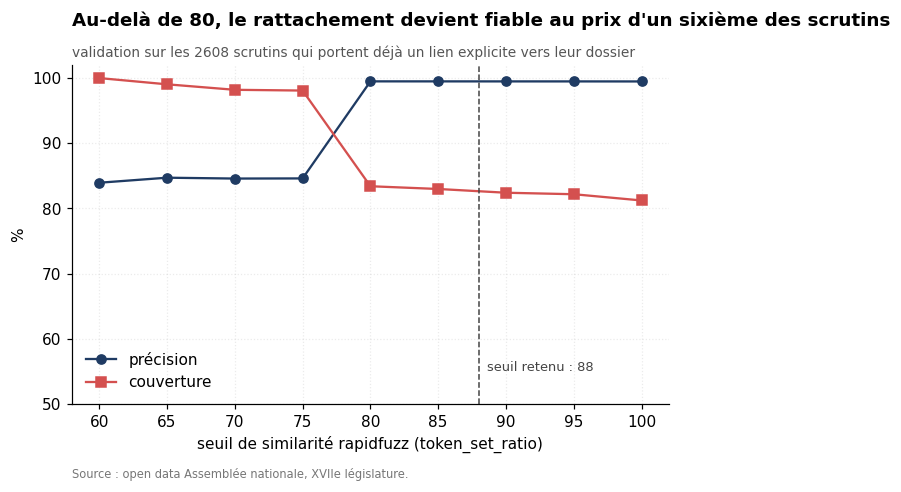

In [8]:
figure = viz.figure_qualite_matching(qualite)

**Lecture.** La marche entre les seuils 75 et 80 est franche : en dessous, on rattache des
textes seulement voisins. Au-delà, la précision plafonne à **99,5 %** pour une couverture de
83 %. Le seuil retenu (88) est pris au milieu du plateau : on perd un sixième des scrutins,
perte assumée et chiffrée, plutôt qu'un sixième de lignes fausses.

**Comment on est passé de 95,7 % à 99,5 %.** La première version s'arrêtait à la similarité
de titre et plafonnait à 95,7 %. En relisant les erreurs, le motif saute aux yeux :
l'Assemblée ouvre un dossier distinct par lecture, et plusieurs dossiers portent
*exactement* le même titre. Un score de 100 ne départage alors rien. L'arbitrage par la
date du scrutin règle le problème.

In [9]:
scrutins = charger("scrutins_rattaches")
repartition = scrutins["origine_lien"].value_counts()
print(repartition.to_string())
print(f"\ntaux de rattachement global : "
      f"{100 * (1 - repartition.get('aucun', 0) / len(scrutins)):.1f} %")
print(f"dénominations avec plusieurs dossiers homonymes : "
      f"{(scrutins['n_candidats_ex_aequo'] > 1).sum():,} scrutins concernés".replace(",", " "))

origine_lien
fuzzy      5041
declare    2629
aucun       785

taux de rattachement global : 90.7 %
dénominations avec plusieurs dossiers homonymes : 3 523 scrutins concernés


### 2.3 Rattacher une activité HATVP à un texte de loi

Là, aucune vérité terrain n'existe. Il faut relire à la main.

**Première tentative.** Secteur compatible, domaine compatible, mot-clé du texte présent,
exercice recouvrant la fenêtre de débat → 904 activités retenues pour la loi agricole. Un
échantillon relu une à une donne une précision d'environ **16 %**. Les faux positifs
viennent de mots-clés trop généraux attrapés hors contexte (« filière », « haie »).

**Deuxième tentative, retenue.** Deux niveaux explicites :

| Niveau | Règle | Usage |
| --- | --- | --- |
| 1 | l'objet déclaré **nomme** le texte (intitulé officiel ou alias d'usage, en sous-chaîne exacte) | variable d'analyse |
| 2 | voisinage thématique (l'ancienne règle) | description de l'écosystème, jamais preuve |

In [10]:
ciblage = charger("ciblage_hatvp")
bilan = (ciblage.groupby("texte_cle")
         .agg(eligibles=("eligible", "sum"),
              niveau_1=("cible_nommee", "sum"),
              niveau_2=("cible_thematique", "sum"))
         .reindex([t.cle for t in config.TEXTES_CIBLES]))
bilan["organisations_niveau_1"] = (
    ciblage[ciblage["cible_nommee"]].groupby("texte_cle")["identifiant_national"]
    .nunique().reindex(bilan.index).fillna(0).astype(int))
bilan

,eligibles,niveau_1,niveau_2,organisations_niveau_1
texte_cle,,,,
agriculture,11501,29,904,18
defense,11502,14,44,11
fraudes,11948,165,16,53
logement,11501,0,419,0


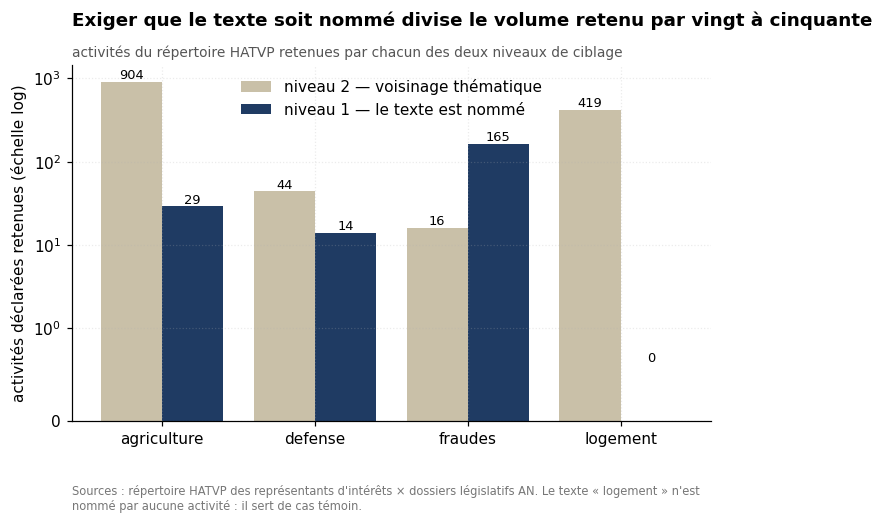

In [11]:
figure = viz.figure_intensite_lobbying(ciblage)

**Le cas témoin.** Le texte `logement` est thématiquement proche de 419 activités, et
nommé par **zéro**. Si le voisinage thématique mesurait le ciblage, ce chiffre serait
impossible. C'est la démonstration la plus économique que « proximité de thème » n'est pas
« ciblage » — et la raison pour laquelle `logement` est exclu de la modélisation.

### 2.4 Pourquoi aucune similarité floue au niveau 1

Une version intermédiaire utilisait `partial_token_set_ratio` entre le titre du texte et
l'objet déclaré. Elle retenait 11 170 activités sur 11 501, dont des déclarations sur le
PLFSS pour la loi agricole. C'est le comportement normal de ce scorer. Démonstration :

In [12]:
from rapidfuzz import fuzz

from lobbynomics.parse_an import normaliser

texte = config.TEXTES_PAR_CLE["defense"]
hors_sujet = normaliser("PLFSS : demander la préservation de l'accès aux traitements onéreux")
print(f"partial_token_set_ratio(titre LPM, objet PLFSS) = "
      f"{fuzz.partial_token_set_ratio(normaliser(texte.libelle), hors_sujet):.0f}  ← inutilisable")
print(f"règle retenue (le texte est-il nommé ?)         = "
      f"{matching.nomme_le_texte(hors_sujet, texte)}")
print(f"  et sur un objet qui nomme vraiment la LPM     = "
      f"{matching.nomme_le_texte(normaliser('LPM 2024-2030 : défendre la sanctuarisation'), texte)}")

partial_token_set_ratio(titre LPM, objet PLFSS) = 100  ← inutilisable
règle retenue (le texte est-il nommé ?)         = False
  et sur un objet qui nomme vraiment la LPM     = True


Le flou est le bon outil pour comparer **deux titres** (section 2.1). Il est le mauvais
outil pour chercher un titre **dans un paragraphe**.

### 2.5 L'audit manuel

60 paires tirées au sort, 20 par niveau, relues une à une. Les cas plausibles mais
invérifiables sont annotés `incertain` et **exclus** du calcul : les ranger d'un côté ou de
l'autre fabriquerait le résultat.

In [13]:
audit = pd.read_csv(config.PROCESSED / "audit_ciblage_a_annoter.csv")
matching.precision_par_niveau(audit)

,n_annote,n_vrais,n_incertains,precision
niveau_ciblage,,,,
0 - écarté,20,0,0,0.000
1 - texte nommé,20,20,0,1.000
2 - voisinage thématique,20,1,4,0.062


In [14]:
mesures = matching.taux_erreur(audit, colonne="cible_nommee")
print(f"précision du niveau 1 : {100 * mesures['precision']:.0f} %  "
      f"({mesures['vp']} vrais positifs, {mesures['fp']} faux positifs)")
print(f"rappel sur l'échantillon : {100 * mesures['rappel']:.0f} %  "
      f"({mesures['fn']} activité ciblante manquée)")
print(f"paires jugées incertaines, exclues du calcul : {mesures['n_incertain']}")

précision du niveau 1 : 100 %  (20 vrais positifs, 0 faux positifs)
rappel sur l'échantillon : 95 %  (1 activité ciblante manquée)
paires jugées incertaines, exclues du calcul : 4


L'unique faux négatif écrivait « PJL Agricole », forme absente de la liste d'alias
initiale. L'alias a été ajouté, ce qui a capturé trois activités supplémentaires, toutes
vérifiées et correctes. Cette itération est documentée plutôt que masquée : le seuil n'a pas
été réglé sur le résultat final, une erreur identifiée a été corrigée.

**Attention à la lecture** : l'échantillon est stratifié, pas aléatoire simple. Ces
précisions valent *par strate* et ne s'extrapolent pas en taux global.

### 2.6 Un contre-exemple : quand la source fournit la clé

In [15]:
deputes = charger("deputes_hatvp")
print(f"députés appariés à leur fiche HATVP par le champ `uri_hatvp` (clé exacte) : "
      f"{100 * deputes['nb_declarations'].notna().mean():.0f} %")
print(f"appariés au contenu des déclarations par nom normalisé (approximatif)    : "
      f"{100 * deputes['nb_interets'].gt(0).mean():.0f} %")
deputes.loc[deputes["uri_hatvp"].notna(),
            ["nom_complet", "groupe_abrev", "departement", "uri_hatvp"]].head(3)

députés appariés à leur fiche HATVP par le champ `uri_hatvp` (clé exacte) : 88 %
appariés au contenu des déclarations par nom normalisé (approximatif)    : 78 %


,nom_complet,groupe_abrev,departement,uri_hatvp
0,Alain David,SOC,Gironde,https://www.hatvp.fr/pages_nominatives/david-a...
2,Jérôme Guedj,SOC,Essonne,https://www.hatvp.fr/pages_nominatives/guedj-j...
3,David Habib,LIOT,Pyrénées-Atlantiques,https://www.hatvp.fr/pages_nominatives/habib-d...


L'open data de l'Assemblée publie l'URL de la fiche HATVP de chaque député. Aucun fuzzy
matching n'est nécessaire. La leçon, qui vaut au-delà de ce projet : **chercher la clé
fournie par la source avant d'inventer la sienne.**

## 3. Qui gravite autour de ces textes ?

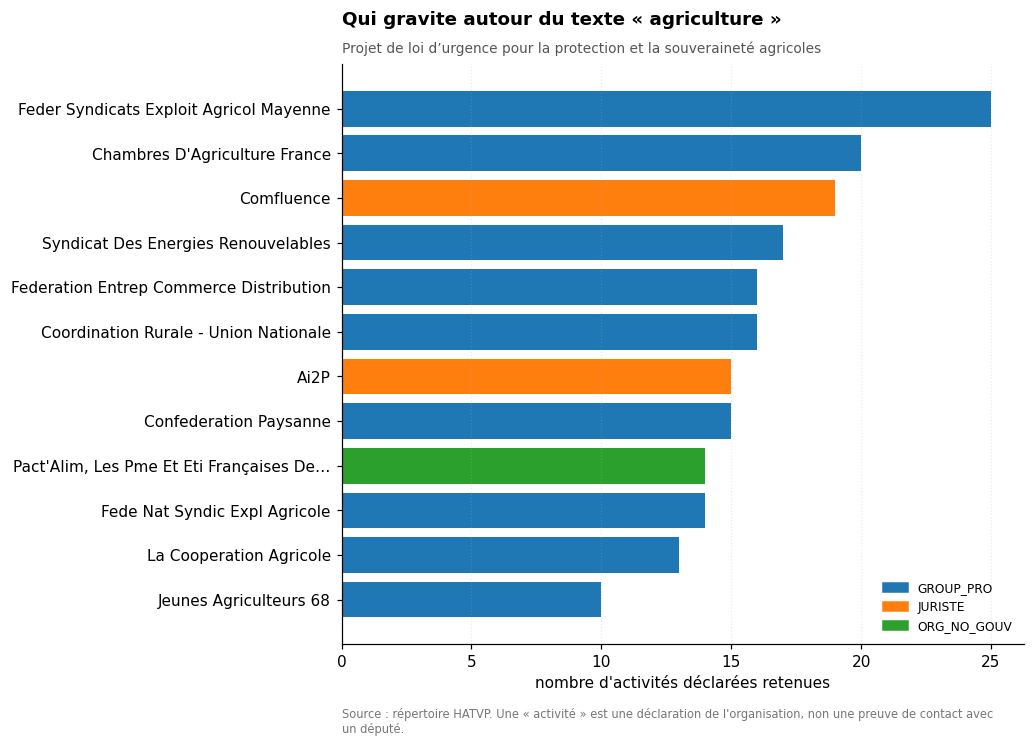

In [16]:
figure = viz.figure_top_organisations(ciblage, "agriculture")

Syndicats agricoles, chambres d'agriculture, interprofessions, mais aussi cabinets de
conseil en affaires publiques, qui déclarent pour le compte de clients. La catégorie de
l'organisation est déclarée par elle-même, et explique une partie de la diversité.

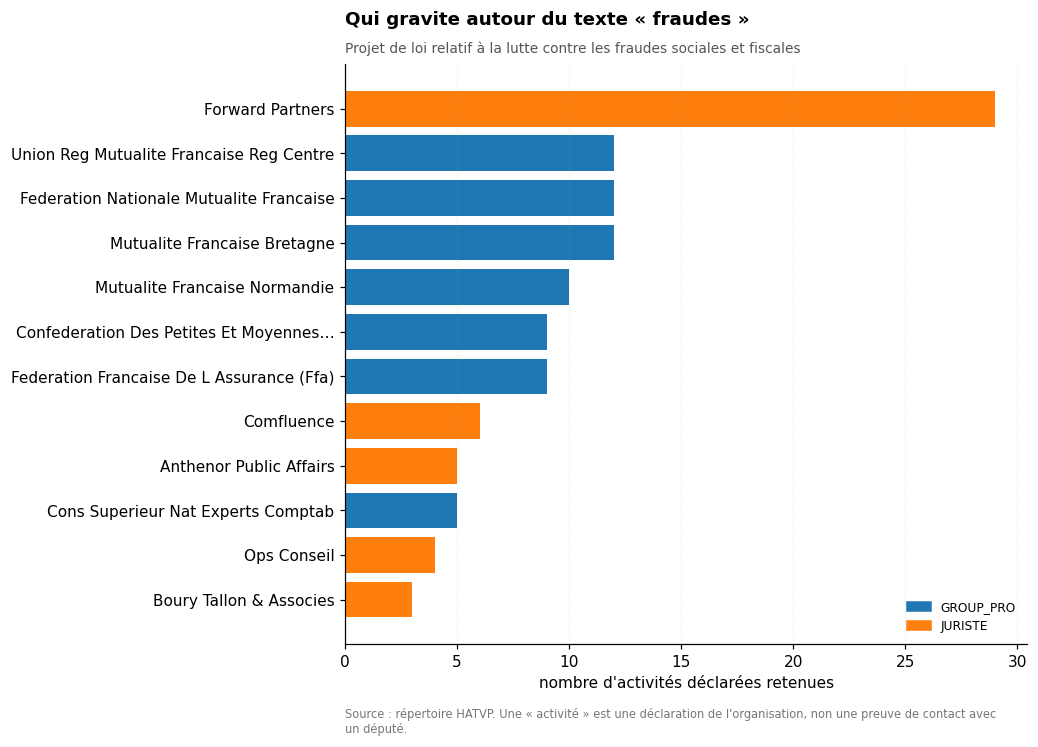

In [17]:
figure = viz.figure_top_organisations(ciblage, "fraudes")

Sur la lutte contre les fraudes, la population est tout autre : mutuelles, fédérations
professionnelles, et des acteurs qui défendent des positions opposées. Deux exemples
littéraux, pris dans les objets déclarés de niveau 1 :

In [18]:
fraudes = ciblage[(ciblage["texte_cle"] == "fraudes") & ciblage["cible_nommee"]]
for _, ligne in fraudes.drop_duplicates("denomination").head(6).iterrows():
    print(f"• {ligne['denomination'][:38]:<40} {str(ligne['objet'])[:105]}")

• FED DEP ENTREPRENEUR ARTISAN BATIMENT    Inscrire des limitation de sous-traitance dans le projet de loi relatif à la lutte contre les fraudes soc
• STRATEGIES & PUBLICS                     PJL Fraudes sociales et fiscales : renforcer le dispositif de lutte contre la fraude au compteur d'électr
• REGIE AUTONOME DES TRANSPORTS PARISIEN   PJL Lutte contre les fraudes sociales et fiscales : Obtenir des moyens supplémentaires de lutte contre la
• FEDERAT BATIM TRAVAUX PUBLIC REGION HA   Inscrire dans la loi relative à la lutte contre les fraudes sociales et fiscales des dispositions destiné
• FED DEP BATIMENT TRAVAUX PUBLIC CALVAD   Proposer des amendements pour encadrer la sous-traitance dans le BTP et limiter les fraudes sociales et f
• FEDERATION DES BATIMENTS ET DES TP DE    inscrire dans le projet de loi visant à lutter contre les fraudes sociales et fiscales, la limitation de 


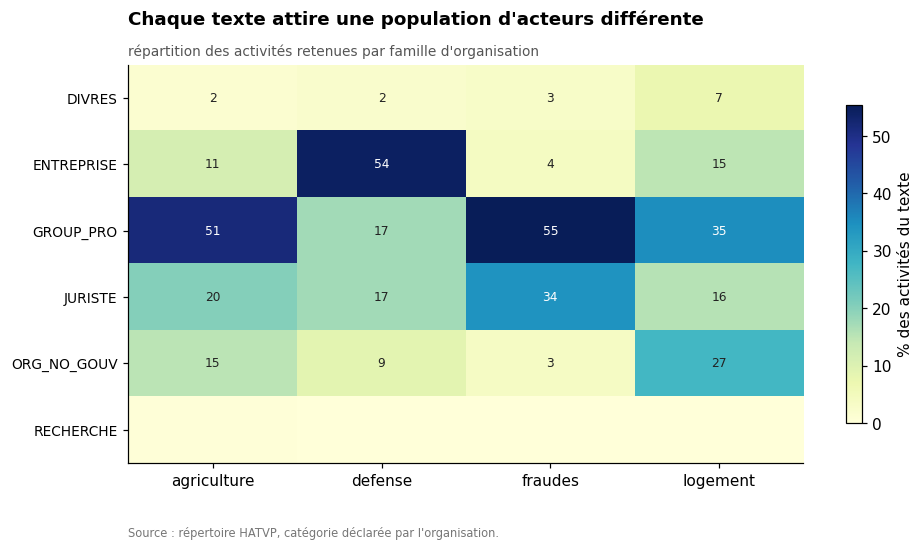

In [19]:
figure = viz.figure_secteurs_textes(ciblage)

Chaque texte attire une population d'acteurs différente : entreprises et sociétés de
conseil sur la défense, organisations professionnelles et associations sur l'agriculture.
Cette figure utilise les deux niveaux de ciblage, puisqu'elle décrit un écosystème et ne
prétend à aucun rattachement individuel.

## 4. Les votes

### 4.1 Le vote final ne contient aucune information à expliquer

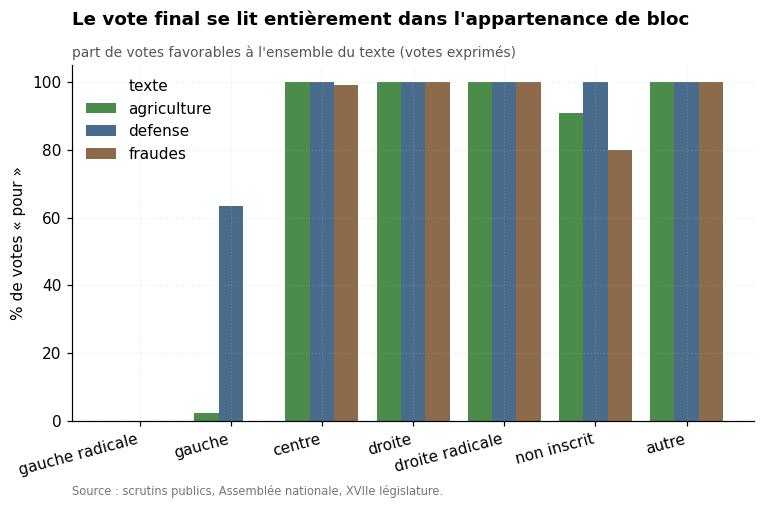

In [20]:
table_finale = charger("analyse_votes_finaux")
figure = viz.figure_votes_par_bloc(table_finale)

In [21]:
models.pouvoir_predictif_bloc(table_finale)

,n,part_pour,exactitude_regle_bloc,nb_votes_atypiques
texte_cle,,,,
agriculture,547,0.6746,0.9945,3
defense,562,0.7829,0.9342,37
fraudes,557,0.6517,0.9946,3


**Lecture.** La règle « chaque député vote comme la majorité de son bloc » se trompe sur
**3 votes sur 547** pour la loi agricole, 3 sur 557 pour les fraudes, 37 sur 562 pour la
loi de programmation militaire — ce dernier texte étant le seul à fracturer un bloc.

Conséquence directe pour la modélisation : un logit avec effets fixes de bloc **ne peut pas
converger**, parce que cinq blocs sur sept votent à 0 % ou 100 %. Le code le détecte et le
dit, au lieu d'afficher des écarts-types astronomiques.

In [22]:
vote = models.modele_vote_final(table_finale)
print(f"observations : {vote['n']}")
print(f"part des observations dans une modalité parfaitement séparée : "
      f"{100 * vote['part_observations_separees']:.0f} %")
print(f"modèle identifiable : {vote.get('identifiable')}\n")
vote["separation"]

vote final : ajustement impossible (LinAlgError) — séparation quasi complète


observations : 1666
part des observations dans une modalité parfaitement séparée : 55 %
modèle identifiable : False



,part_cible,effectif,separe
bloc,,,
autre,1.0000,50,True
centre,0.9976,420,False
droite,1.0000,247,True
droite radicale,1.0000,361,True
gauche,0.2230,296,False
gauche radicale,0.0000,260,True
non inscrit,0.9062,32,False


Chercher un effet du lobbying ici reviendrait à chercher de la variance là où il n'y en a
pas. Il faut descendre d'un niveau.

### 4.2 La dissidence sur les amendements : le bon niveau d'observation

In [23]:
dissidence = charger("analyse_dissidence")
print(f"{len(dissidence):,} votes exprimés".replace(",", " "),
      f"sur {dissidence['scrutin_uid'].nunique()} scrutins d'amendements,",
      f"{dissidence['acteur_ref'].nunique()} députés")
print(f"taux de dissidence global : {100 * dissidence['dissident'].mean():.2f} %")
print(f"députés ayant dissidé au moins une fois : "
      f"{100 * dissidence.groupby('acteur_ref')['dissident'].max().mean():.0f} %")

89 472 votes exprimés sur 970 scrutins d'amendements, 554 députés
taux de dissidence global : 4.31 %
députés ayant dissidé au moins une fois : 83 %


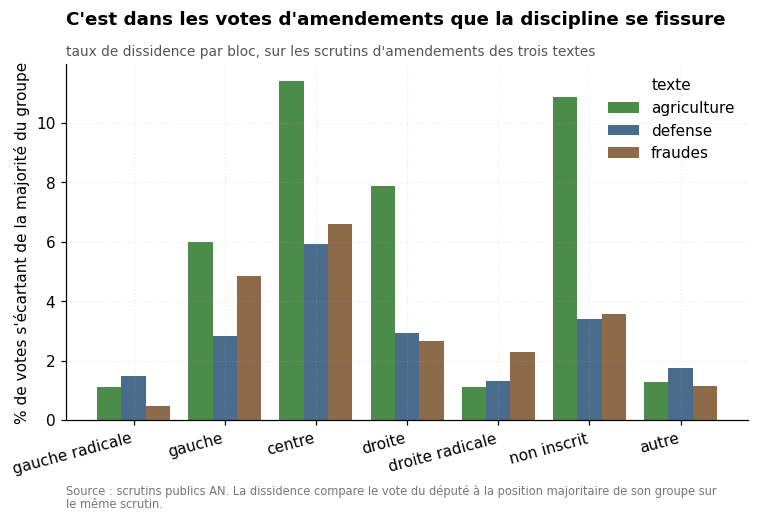

In [24]:
figure = viz.figure_dissidence(dissidence)

La discipline n'est pas la même partout : les blocs de gouvernement et les non-inscrits
s'écartent nettement plus souvent de leur groupe que les blocs les plus structurés. C'est
cette variation — 4,3 % des votes — qui rend une régression possible.

## 5. L'exposition au lobbying : une variable qu'il faut construire

Le répertoire HATVP dit « j'ai contacté des députés ». Il ne dit **jamais** lequel. Une
exposition individuelle ne peut donc pas être lue dans les données ; elle doit être
construite.

**Méthode.** Un espace TF-IDF commun est appris sur l'union de deux corpus — les exposés
des motifs des amendements de chaque député sur le texte, et les objets déclarés des lobbies
de niveau 1 — puis on calcule les cosinus. Démonstration sur un cas fabriqué, où l'on sait
quelle réponse attendre :

In [25]:
amendements_test = pd.DataFrame([
    {"amendement_uid": "A1", "type_auteur": "Député", "acteur_ref": "Députée A", "adopte": True,
     "expose": "Sanctuariser la trajectoire budgétaire de la programmation militaire et "
               "garantir les commandes d'armement terrestre. " * 4, "dispositif": ""},
    {"amendement_uid": "A2", "type_auteur": "Député", "acteur_ref": "Député B", "adopte": False,
     "expose": "Protéger les haies bocagères et encadrer l'usage des produits "
               "phytosanitaires en zone de captage. " * 4, "dispositif": ""},
])
lobbies_test = pd.DataFrame([
    {"cible_texte": True, "activite_id": "L1", "denomination": "INDUSTRIE DE DÉFENSE",
     "objet": "Défendre la sanctuarisation de la trajectoire de la programmation militaire "
              "et obtenir des commandes d'armement terrestre"},
    {"cible_texte": True, "activite_id": "L2", "denomination": "ASSOCIATION BOCAGE",
     "objet": "Protéger les haies bocagères et restreindre les produits phytosanitaires "
              "dans les zones de captage"},
])
features.proximite_lobbies(amendements_test, lobbies_test, min_caracteres=50)[
    ["acteur_ref", "proximite_max", "lobby_le_plus_proche"]]

,acteur_ref,proximite_max,lobby_le_plus_proche
0,Député B,1.0,ASSOCIATION BOCAGE
1,Députée A,1.0,INDUSTRIE DE DÉFENSE


Chacun retrouve son homologue lexical. Appliquée aux vraies données :

In [26]:
auteurs = table_finale[table_finale["a_depose_amendement"] & table_finale["proximite_max"].gt(0)]
print(f"députés auteurs d'au moins un amendement sur les trois textes : {len(auteurs)}")
auteurs.groupby("texte_cle")["proximite_max"].describe()[
    ["count", "mean", "50%", "max"]].round(3)

députés auteurs d'au moins un amendement sur les trois textes : 190


,count,mean,50%,max
texte_cle,,,,
agriculture,100.0,0.052,0.045,0.146
defense,47.0,0.048,0.048,0.092
fraudes,43.0,0.099,0.091,0.207


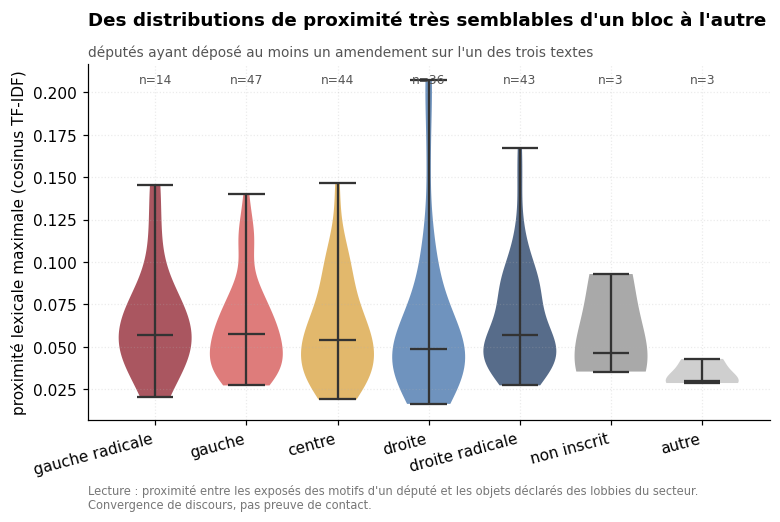

In [27]:
figure = viz.figure_proximite(table_finale)

Les distributions se ressemblent d'un bloc à l'autre : rien, à ce stade, ne distingue un
bord politique. Les quelques valeurs hautes sont des cas individuels, pas une tendance de
groupe.

### 5.1 Le graphe biparti

Chaque arête relie une organisation à un député dont les amendements emploient un
vocabulaire proche de l'objet qu'elle a déclaré. **Elle ne signifie pas qu'un contact a eu
lieu.**

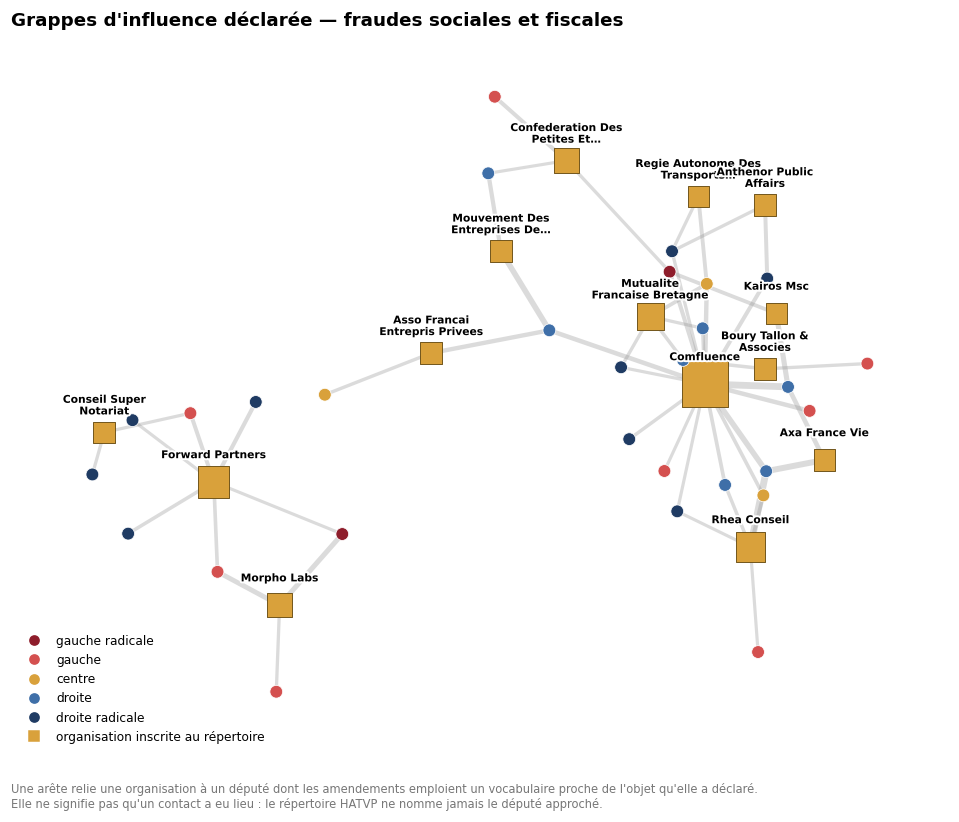

In [28]:
aretes = charger("graphe_aretes")
figure, graphe = viz.figure_graphe_biparti(
    aretes[aretes["texte_cle"] == "fraudes"], deputes, titre_texte="fraudes sociales et fiscales")

In [29]:
viz.metriques_graphe(graphe).head(8)

,noeud,type,degre,centralite_degre,centralite_intermediarite
0,🏛 Comfluence,organisation,15,0.357143,0.442509
1,🏛 Forward Partners,organisation,6,0.142857,0.042973
2,🏛 Rhea Conseil,organisation,5,0.119048,0.037166
3,🏛 Mutualite\nFrancaise Bretagne,organisation,4,0.095238,0.101045
4,Fabrice Brun,depute,3,0.071429,0.031359
5,Bertrand Bouyx,depute,3,0.071429,0.002323
6,Alexandre Dufosset,depute,3,0.071429,0.061556
7,Christophe Blanchet,depute,3,0.071429,0.004646


Les nœuds les plus centraux sont des organisations qui déclarent beaucoup d'objets
distincts sur le même texte — mutuelles et fédérations professionnelles sur ce texte-ci.
La centralité mesure ici une **intensité déclarative**, pas une efficacité.

## 6. Modélisation

### 6.1 Ce qui prédit un vote dissident

Logit sur les 87 914 votes d'amendements exploitables, écarts-types **groupés par député** :
un même député apparaît dans des centaines de scrutins, ses erreurs sont corrélées, et des
écarts-types classiques seraient artificiellement petits.

In [30]:
resultat = models.modele_dissidence(dissidence)
print(resultat["formule"])
print(f"\nn = {resultat['n']:,}".replace(",", " "),
      f"| {resultat['n_deputes']} députés",
      f"| taux de dissidence {100 * resultat['taux_dissidence']:.2f} %",
      f"| pseudo-R² = {resultat['pseudo_r2']:.3f}")
resultat["coefficients"][["coefficient", "erreur_standard", "p_value", "odds_ratio", "significatif"]]

dissident ~ proximite_max_std + interet_sectoriel_declare + part_rurale_std + dans_commission_competente + a_depose_amendement + C(bloc) + C(texte_cle)

n = 87 914 | 537 députés | taux de dissidence 4.27 % | pseudo-R² = 0.076


,coefficient,erreur_standard,p_value,odds_ratio,significatif
Intercept,-3.9311,0.2566,0.0000,0.0196,True
C(bloc)[T.centre],1.9240,0.2570,0.0000,6.8483,True
C(bloc)[T.droite],1.4202,0.2621,0.0000,4.1378,True
C(bloc)[T.droite radicale],-0.0461,0.2587,0.8585,0.9549,False
C(bloc)[T.gauche],1.3018,0.2692,0.0000,3.6761,True
C(bloc)[T.gauche radicale],-0.3845,0.2763,0.1640,0.6808,False
C(bloc)[T.non inscrit],1.6732,0.3885,0.0000,5.3289,True
C(texte_cle)[T.defense],-0.6650,0.0670,0.0000,0.5143,True
C(texte_cle)[T.fraudes],-0.4454,0.0654,0.0000,0.6406,True
proximite_max_std,0.0861,0.0493,0.0811,1.0899,False


In [31]:
marges = models.effets_marginaux(resultat["resultat"])
marges[["effet_points_pct", "p_value"]].round(3)

,effet_points_pct,p_value
C(bloc)[T.centre],7.643,0.000
C(bloc)[T.droite],5.642,0.000
C(bloc)[T.droite radicale],-0.183,0.858
C(bloc)[T.gauche],5.172,0.000
C(bloc)[T.gauche radicale],-1.527,0.164
C(bloc)[T.non inscrit],6.647,0.000
C(texte_cle)[T.defense],-2.642,0.000
C(texte_cle)[T.fraudes],-1.770,0.000
proximite_max_std,0.342,0.080
interet_sectoriel_declare,0.718,0.082


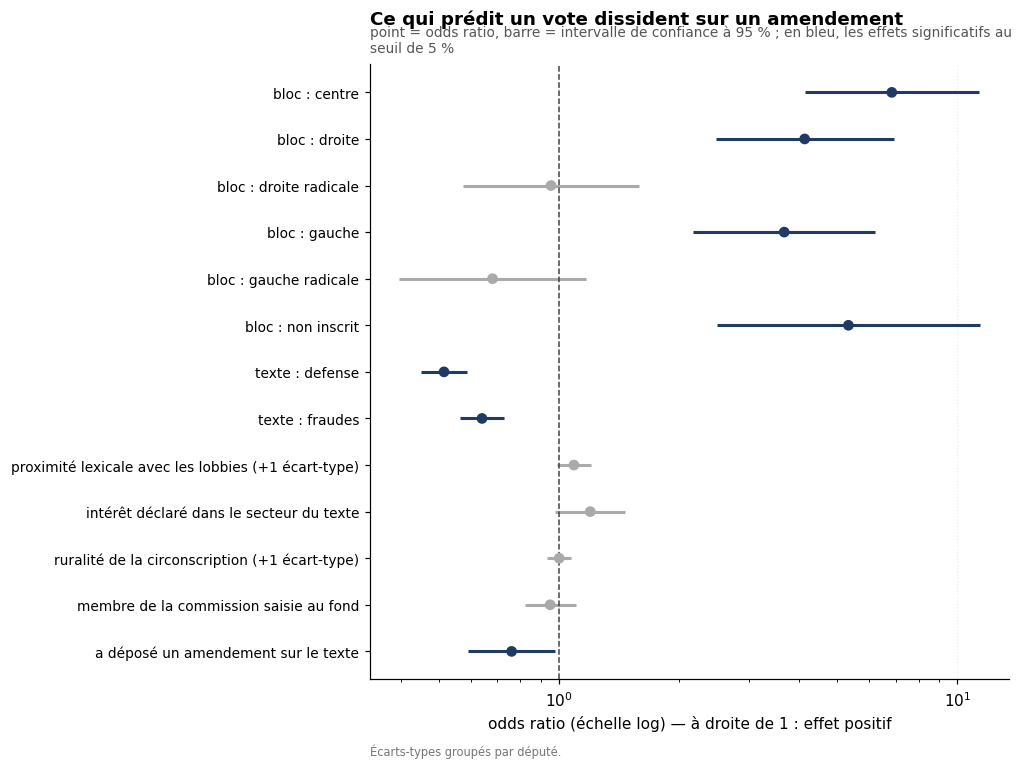

In [32]:
figure = viz.figure_coefficients(
    resultat["coefficients"], titre="Ce qui prédit un vote dissident sur un amendement")

**Lecture, et c'est le résultat central du projet.**

Un écart-type de proximité lexicale supplémentaire est associé à **+0,34 point** de
probabilité de dissidence, et un intérêt sectoriel déclaré à **+0,72 point**. Les deux vont
dans le sens attendu. **Aucun des deux n'est significatif au seuil de 5 %** (p = 0,08 dans
les deux cas). *On ne conclut donc pas à un effet.*

Il faut aussi regarder l'ordre de grandeur : +0,34 point sur un taux de base de 4,3 %, soit
environ 8 % de hausse relative. Même si l'effet était significatif, il serait petit devant
l'effet du bloc politique (+5 à +8 points).

Le seul coefficient net est négatif : un député qui dépose des amendements sur un texte
dissident **moins** (−1,09 point, p = 0,03). Interprétation plausible : déposer des
amendements est un marqueur d'investissement dans la ligne de son groupe, pas de
dissidence.

### 6.2 Qui écrit comme les lobbies ?

In [33]:
convergence = models.modele_convergence(table_finale)
print(f"n = {convergence['n']} députés-textes | pseudo-R² = {convergence['pseudo_r2']:.3f}")
convergence["coefficients"][["coefficient", "p_value", "odds_ratio", "significatif"]]

n = 166 députés-textes | pseudo-R² = 0.014


,coefficient,p_value,odds_ratio,significatif
Intercept,-0.1298,0.8159,0.8783,False
C(bloc)[T.droite],-0.1864,0.6987,0.8300,False
C(bloc)[T.droite radicale],-0.5242,0.2473,0.5920,False
C(bloc)[T.gauche],-0.0855,0.8473,0.9180,False
part_rurale_std,-0.0189,0.9105,0.9813,False
interet_sectoriel_declare,-0.5101,0.2582,0.6005,False
dans_commission_competente,0.1737,0.6229,1.1897,False
log_amendements,0.1449,0.4925,1.1559,False


Aucun coefficient significatif. Ni la ruralité de la circonscription, ni l'appartenance à
la commission saisie au fond, ni les intérêts déclarés ne prédisent le fait d'écrire des
amendements lexicalement proches des demandes des lobbies. Avec 166 observations, la
puissance statistique est faible : l'absence de résultat n'est pas un résultat d'absence.

### 6.3 Robustesse : le vote de deuxième lecture

Les tables sont reconstruites à l'identique sur le second vote sur l'ensemble de chaque
texte. Si la discipline de groupe y est aussi écrasante, la conclusion de la partie 4 ne
tient pas à un scrutin particulier.

In [34]:
lecture2 = charger("analyse_votes_finaux_lecture2")
comparaison = pd.concat([
    models.pouvoir_predictif_bloc(table_finale).assign(lecture="1re"),
    models.pouvoir_predictif_bloc(lecture2).assign(lecture="2e"),
]).set_index("lecture", append=True)
comparaison[["n", "part_pour", "exactitude_regle_bloc", "nb_votes_atypiques"]]

,,n,part_pour,exactitude_regle_bloc,nb_votes_atypiques
texte_cle,lecture,,,,
agriculture,1re,547,0.6746,0.9945,3
defense,1re,562,0.7829,0.9342,37
fraudes,1re,557,0.6517,0.9946,3
agriculture,2e,520,0.5692,0.9327,35
defense,2e,488,0.7684,0.9242,37
fraudes,2e,517,0.6480,0.9826,9


Même conclusion aux deux lectures : la discipline de bloc explique de 93 à 99 % des votes.

## 7. Conclusion

**Ce qu'on trouve.**

1. Sur le **vote final**, il n'y a rien à expliquer : la discipline de groupe prédit 93 à
   99 % des votes. Toute recherche d'un effet du lobbying à ce niveau serait une illusion
   statistique.
2. Dans les **votes d'amendements**, où 4,3 % des positions s'écartent du groupe, la
   proximité lexicale avec les demandes déclarées des lobbies et les intérêts sectoriels
   déclarés vont dans le sens attendu, mais **ne sont pas significatifs** (p ≈ 0,08). On ne
   conclut pas.
3. Le lobbying déclaré est **très inégalement réparti** : 165 activités nomment le texte sur
   les fraudes, 29 la loi agricole, **aucune** le texte sur le logement, pourtant entouré de
   419 activités thématiquement proches.

**Ce qu'on ne peut pas dire.** Rien sur la causalité. Le répertoire ne nomme jamais le
député approché : ce qui est mesuré est une convergence de vocabulaire, compatible avec une
influence, avec un ciblage de députés déjà convaincus — la lecture la plus courante dans la
littérature — ou avec le simple jargon partagé d'un secteur. Et le registre est
autodéclaratif : on mesure le lobbying *déclaré*, sous-ensemble inconnu du lobbying réel,
dont l'exhaustivité est régulièrement contestée par Transparency International.

**Ce que le projet apporte vraiment.** Une chaîne reproductible qui rend trois bases
officielles comparables, et surtout **une mesure du prix de ce rapprochement** : 99,5 % de
précision sur le rattachement interne à l'Assemblée après arbitrage temporel, 100 % sur
20 paires relues pour le ciblage HATVP strict, contre 6 % pour la règle thématique que nous
avions d'abord écrite. Le résultat méthodologique le plus solide du projet est négatif :
**une règle de matching plausible peut être fausse neuf fois sur dix, et seule une relecture
manuelle le révèle.**

**Pistes.** Étendre aux textes budgétaires, où le lobbying déclaré est le plus dense ;
remplacer le TF-IDF par un modèle de phrases pour capter l'opposition sémantique que le
cosinus lexical ignore ; et exploiter le volet pantouflage, dont les données
(`hatvp_interets_deputes`, 11 438 lignes) sont déjà chargées ici mais pas encore analysées.